# AWA2 — CREAM Training Analysis
Loads TensorBoard event files and intervention results from the AWA2 CREAM experiment.
- Section 1: Loss & accuracy curves from TensorBoard
- Section 2: Intervention curves

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

EXPERIMENTS_ROOT = Path('/home/dani00003/mCREAM/experiments')

AWA2_CREAM_DIR = EXPERIMENTS_ROOT / 'AWA2' / 'train_cbm' / 'Standard_AWA2'

print('CREAM dir exists:', AWA2_CREAM_DIR.exists())
for p in sorted(AWA2_CREAM_DIR.rglob('events.out.*')):
    print(' ', p.relative_to(EXPERIMENTS_ROOT))

CREAM dir exists: True
  AWA2/train_cbm/Standard_AWA2/CREAM/CREAM_awa2/seed_0/lightning_logs/version_0/events.out.tfevents.1785183953.dani00003-177898.0-frigg.hpc.uni-saarland.de.74.0
  AWA2/train_cbm/Standard_AWA2/CREAM/CREAM_awa2/seed_0/lightning_logs/version_0/events.out.tfevents.1785210691.dani00003-177898.0-frigg.hpc.uni-saarland.de.74.1
  AWA2/train_cbm/Standard_AWA2/CREAM/CREAM_awa2/seed_0/lightning_logs/version_0/events.out.tfevents.1785211180.dani00003-177898.0-frigg.hpc.uni-saarland.de.74.2
  AWA2/train_cbm/Standard_AWA2/CREAM/CREAM_awa2/seed_1/lightning_logs/version_0/events.out.tfevents.1785183953.dani00003-177899.0-balder.hpc.uni-saarland.de.75.0
  AWA2/train_cbm/Standard_AWA2/CREAM/CREAM_awa2/seed_1/lightning_logs/version_0/events.out.tfevents.1785211100.dani00003-177899.0-balder.hpc.uni-saarland.de.75.1
  AWA2/train_cbm/Standard_AWA2/CREAM/CREAM_awa2/seed_1/lightning_logs/version_0/events.out.tfevents.1785211489.dani00003-177899.0-balder.hpc.uni-saarland.de.75.2
  AWA2/t

---
# Section 1 — Loss & Accuracy Curves

In [2]:
def load_tensorboard(log_dir):
    """Load all scalar tags from a TensorBoard event file directory."""
    ea = EventAccumulator(str(log_dir))
    ea.Reload()
    tags = ea.Tags()['scalars']
    data = {}
    for tag in tags:
        events = ea.Scalars(tag)
        data[tag] = pd.DataFrame({
            'step':  [e.step  for e in events],
            'value': [e.value for e in events],
        })
    return data

tb = {}
version_dirs = sorted(AWA2_CREAM_DIR.rglob('lightning_logs/version_*'))
if not version_dirs:
    print('No version dirs found — job may still be running.')
else:
    TB_DIR = version_dirs[-1]
    print('Loading from:', TB_DIR)
    tb = load_tensorboard(TB_DIR)
    print('Available tags:', list(tb.keys()))

Loading from: /home/dani00003/mCREAM/experiments/AWA2/train_cbm/Standard_AWA2/CREAM/CREAM_best/lightning_logs/version_0
Available tags: ['hp_metric', 'lr-Adam', 'train_task_loss', 'train_task_accuracy', 'train_concept_loss', 'train_concept_accuracy', 'train_total_loss', 'train_task_loss_percent', 'epoch', 'val_task_loss', 'val_task_accuracy', 'val_concept_loss', 'val_concept_accuracy', 'val_total_loss', 'val_task_loss_percent', 'test_task_loss', 'test_task_accuracy', 'test_concept_loss', 'test_concept_accuracy', 'test_total_loss', 'test_task_loss_percent']


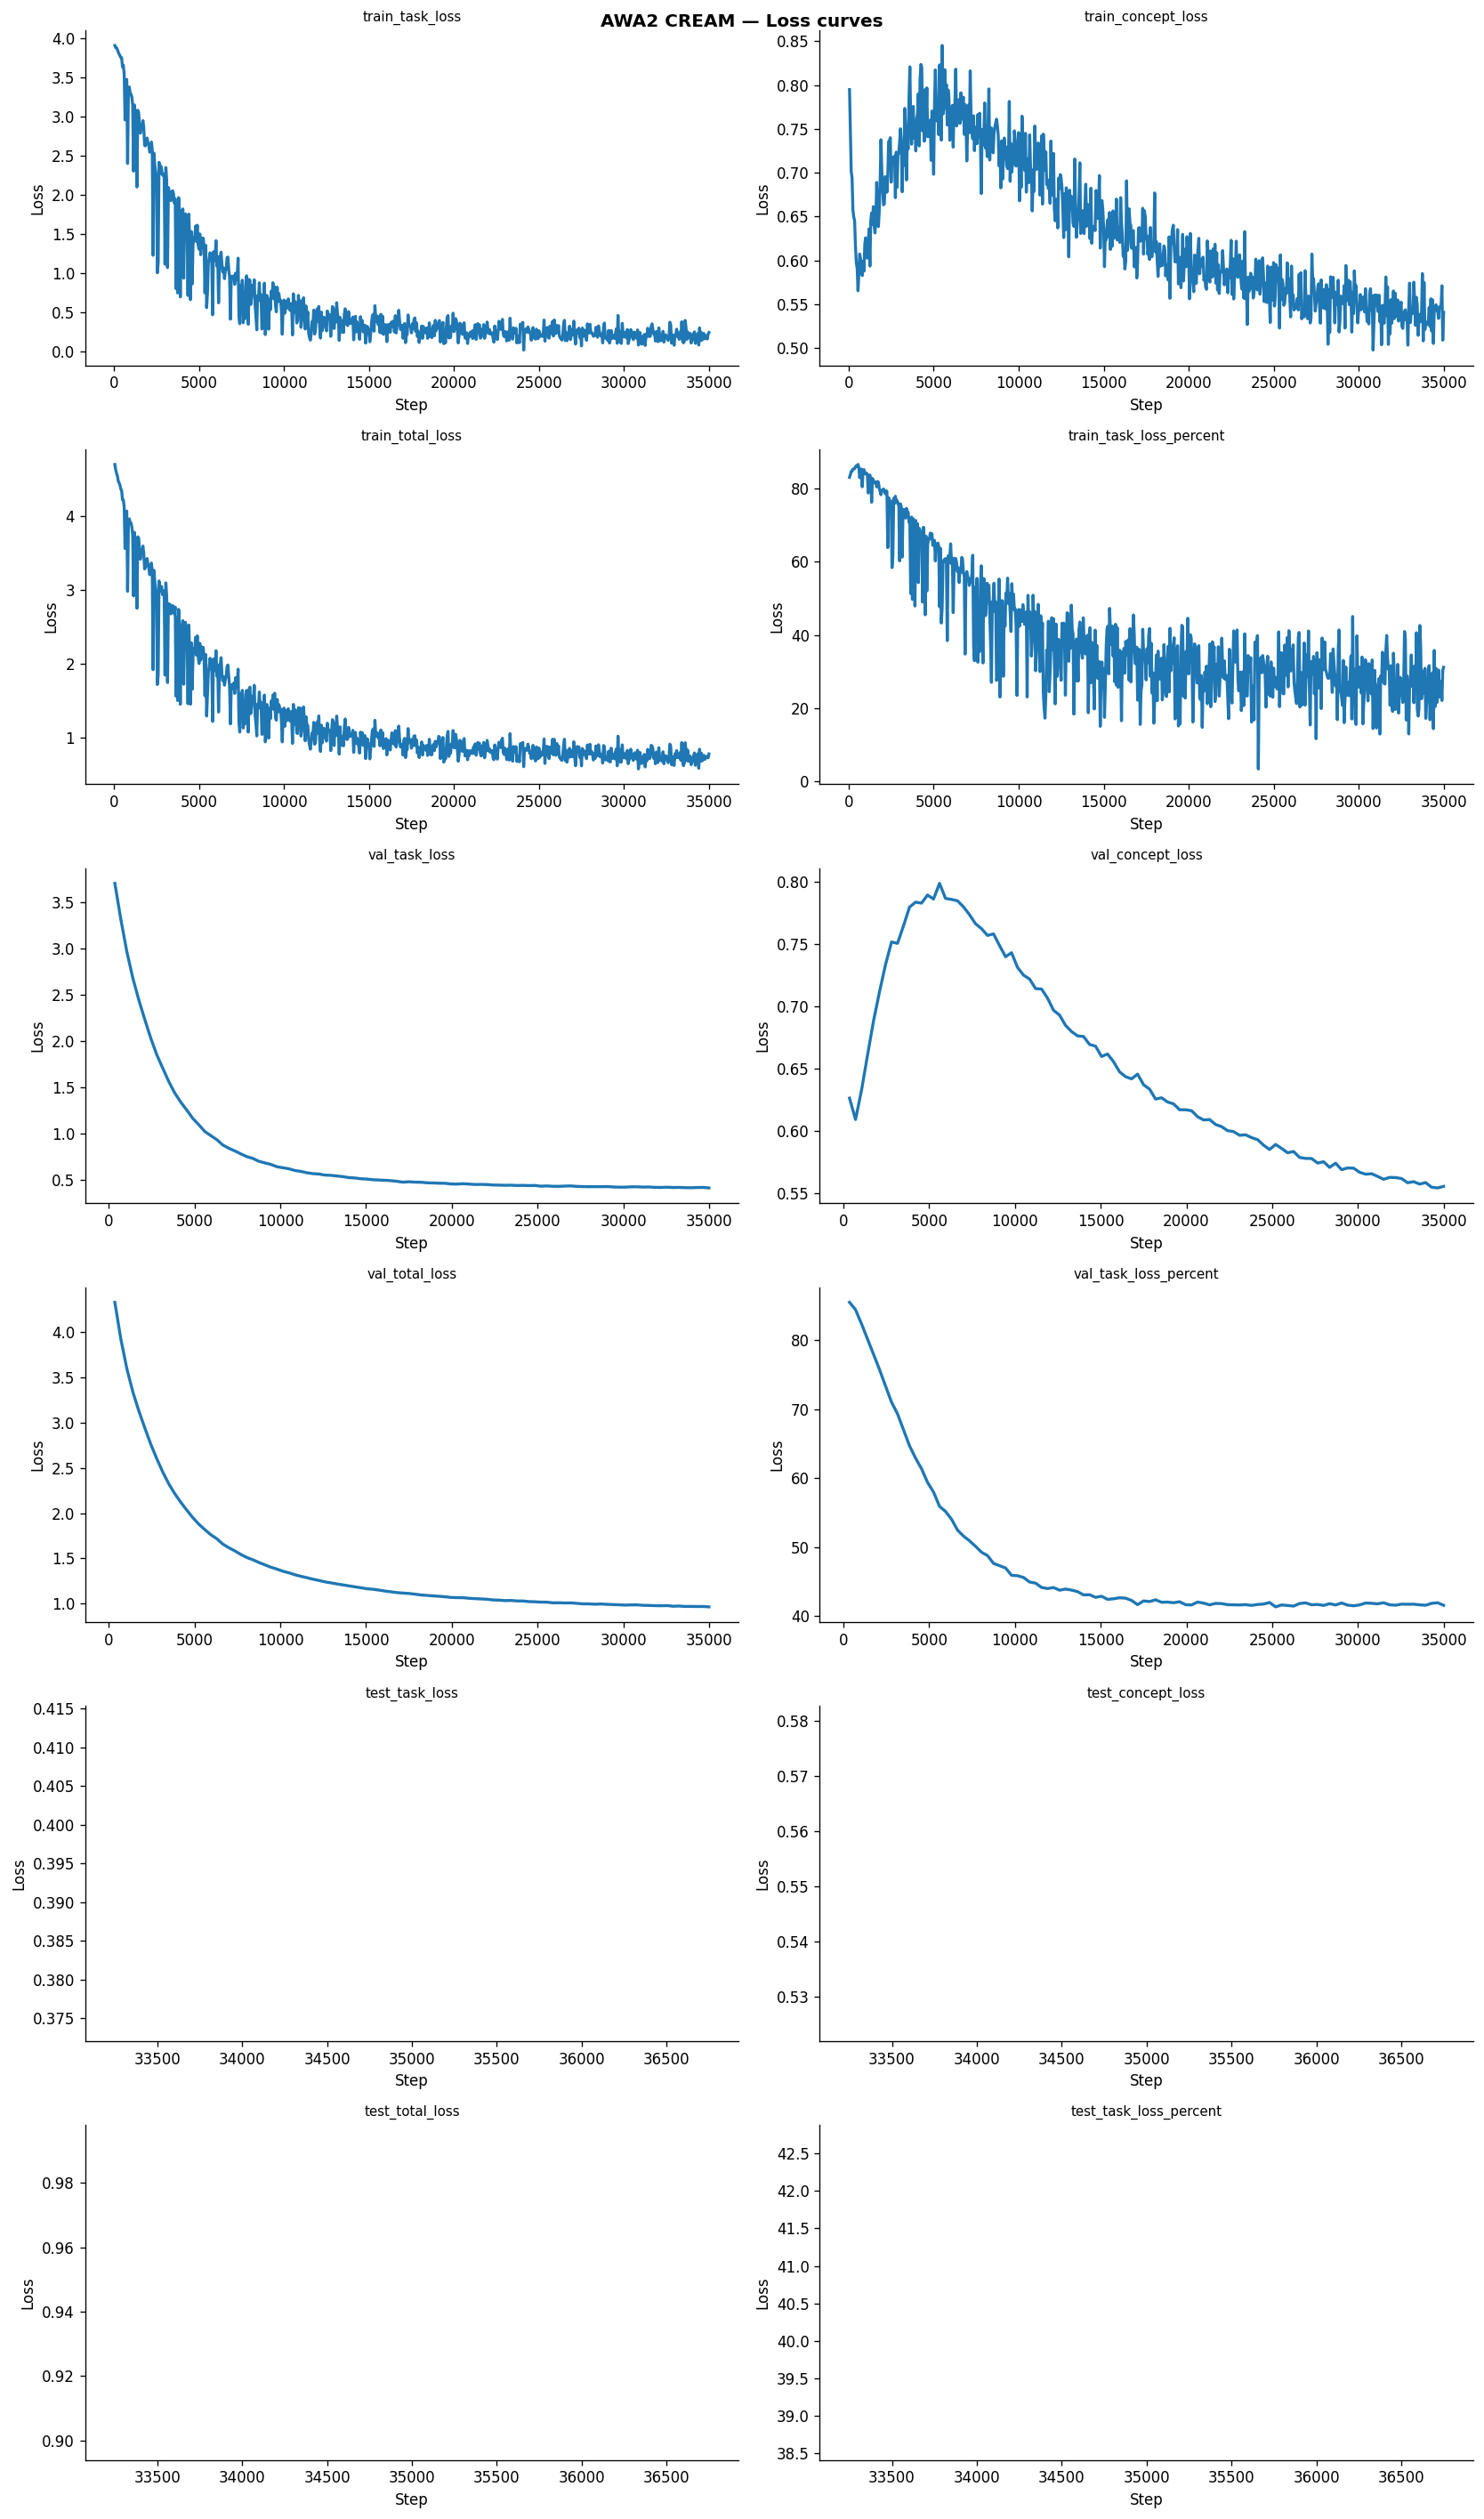

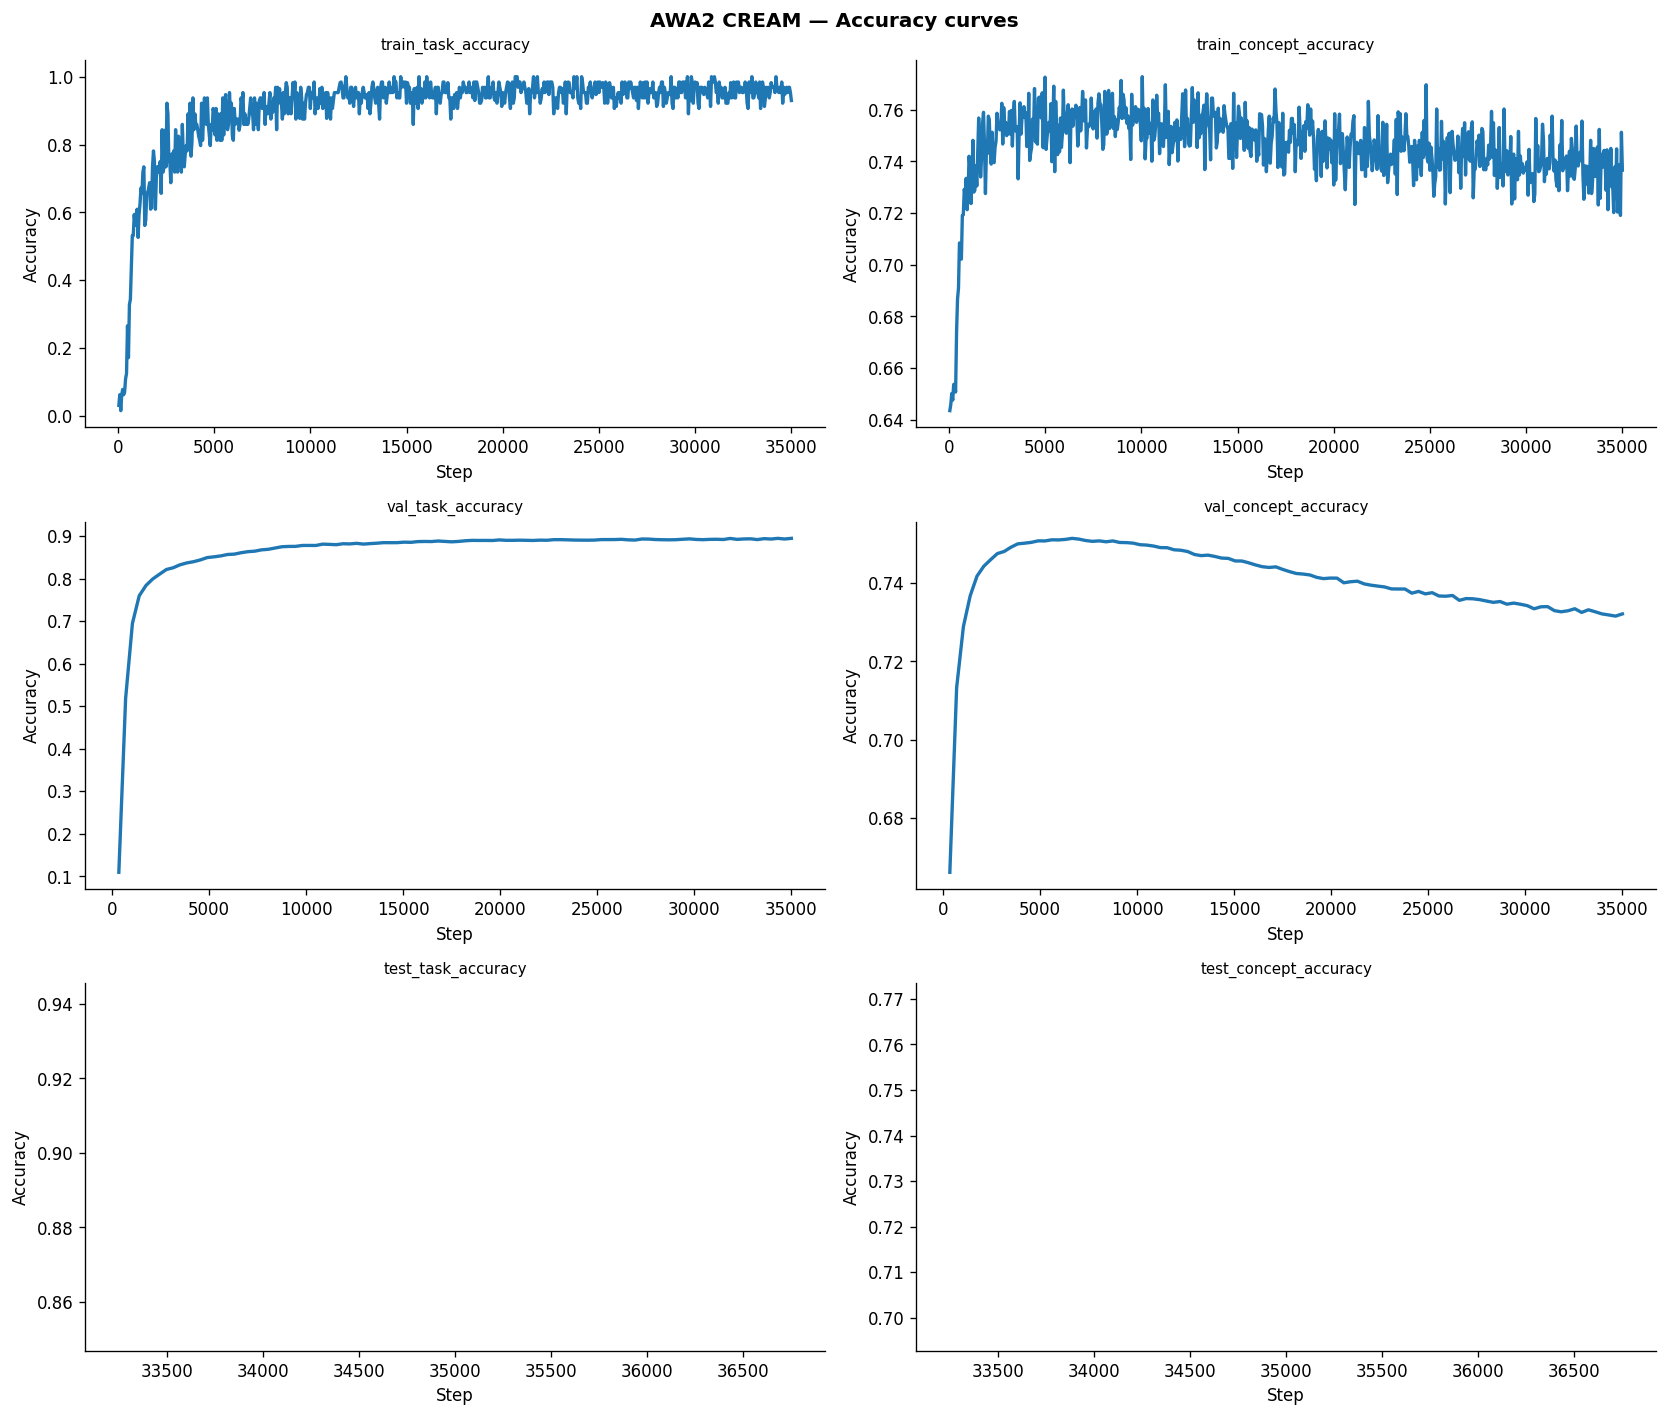

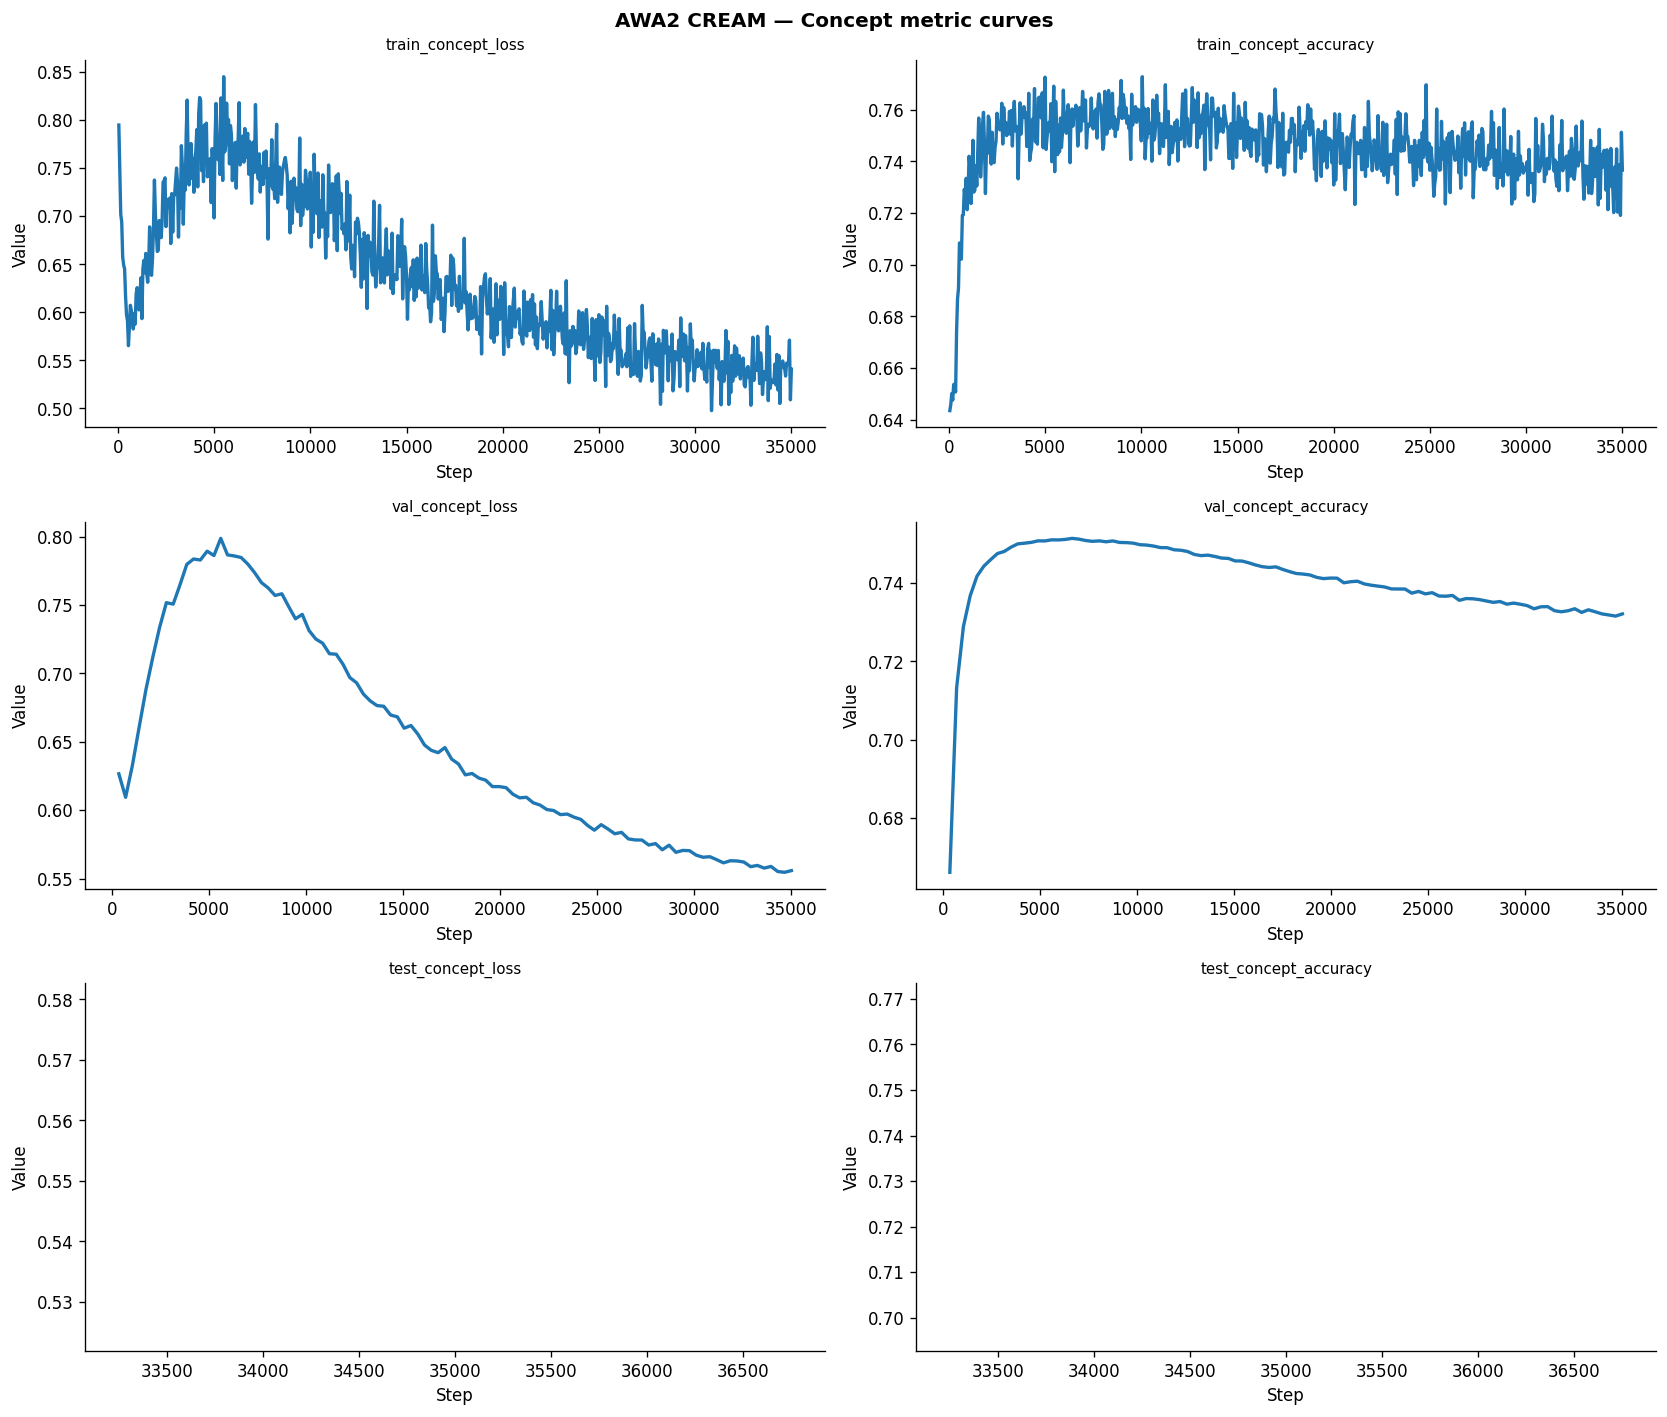

In [3]:
# Tags to plot — adjust if your run uses different names
LOSS_TAGS = [t for t in tb if 'loss' in t.lower()]
ACC_TAGS  = [t for t in tb if 'acc' in t.lower() or 'accuracy' in t.lower()]
CONCEPT_TAGS = [t for t in tb if 'concept' in t.lower()]

def plot_tags(tag_list, title, ylabel, ncols=2):
    if not tag_list:
        print(f'No tags for: {title}')
        return
    nrows = int(np.ceil(len(tag_list) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows), squeeze=False)
    fig.suptitle(title, fontsize=12, fontweight='bold')
    for i, tag in enumerate(tag_list):
        ax = axes[i // ncols][i % ncols]
        df = tb[tag]
        ax.plot(df['step'], df['value'], lw=2)
        ax.set_title(tag, fontsize=9)
        ax.set_xlabel('Step')
        ax.set_ylabel(ylabel)
    # hide unused axes
    for j in range(i + 1, nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_tags(LOSS_TAGS,    'AWA2 CREAM — Loss curves',            'Loss')
plot_tags(ACC_TAGS,     'AWA2 CREAM — Accuracy curves',        'Accuracy')
plot_tags(CONCEPT_TAGS, 'AWA2 CREAM — Concept metric curves',  'Value')

Skipping Loss (train vs val): tags not found


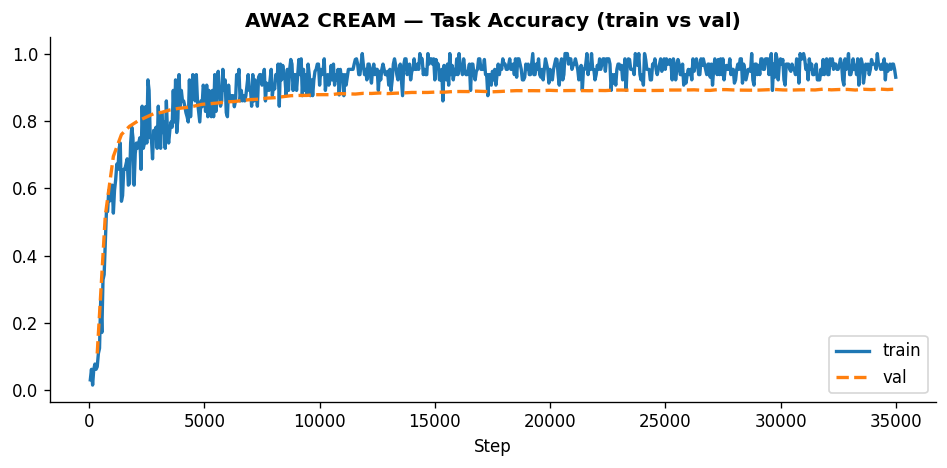

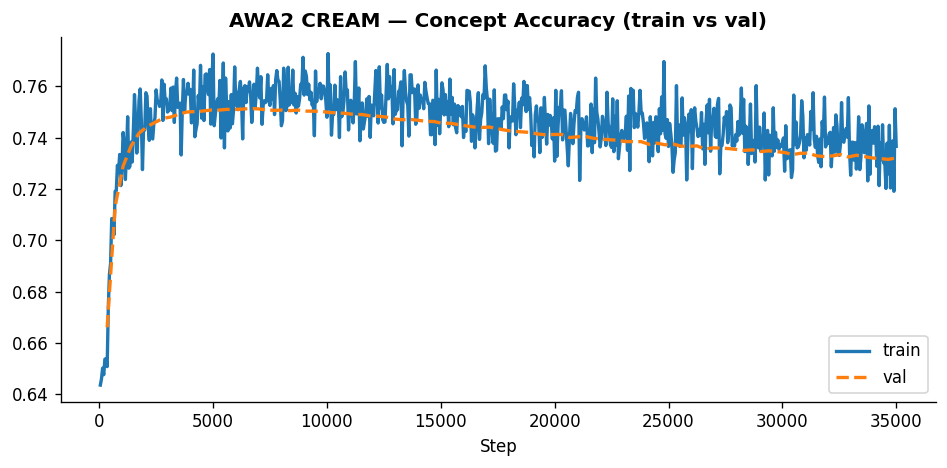

In [4]:
# Overlay train vs val for loss and task accuracy
pairs = [
    ('train_loss', 'val_loss',         'Loss (train vs val)'),
    ('train_task_accuracy', 'val_task_accuracy', 'Task Accuracy (train vs val)'),
    ('train_concept_accuracy', 'val_concept_accuracy', 'Concept Accuracy (train vs val)'),
]

for train_tag, val_tag, title in pairs:
    # fuzzy match — handle step_* prefixes lightning adds
    t_key = next((k for k in tb if train_tag in k), None)
    v_key = next((k for k in tb if val_tag   in k), None)
    if t_key is None and v_key is None:
        print(f'Skipping {title}: tags not found')
        continue
    fig, ax = plt.subplots(figsize=(8, 4))
    if t_key:
        df = tb[t_key]
        ax.plot(df['step'], df['value'], label='train', lw=2)
    if v_key:
        df = tb[v_key]
        ax.plot(df['step'], df['value'], label='val', lw=2, ls='--')
    ax.set_title(f'AWA2 CREAM — {title}', fontweight='bold')
    ax.set_xlabel('Step'); ax.legend()
    plt.tight_layout()
    plt.show()

In [5]:
# Final numbers: best and last value for each val metric
rows = []
for tag, df in tb.items():
    if 'val' not in tag.lower() and 'test' not in tag.lower():
        continue
    best = df['value'].max() if ('acc' in tag.lower()) else df['value'].min()
    last = df['value'].iloc[-1]
    rows.append({'tag': tag, 'best': round(best, 4), 'last': round(last, 4)})

# Also load last_metrics CSV if saved by simple_main
last_metrics_files = sorted(AWA2_CREAM_DIR.rglob('last_metrics/*.csv'))
if last_metrics_files:
    print('=== last_metrics CSV ===')
    for f in last_metrics_files:
        display(pd.read_csv(f))

if rows:
    print('=== TensorBoard val/test numbers ===')
    display(pd.DataFrame(rows).set_index('tag'))
else:
    print('No val/test metrics found yet.')

=== last_metrics CSV ===


,max_epochs,seed,experiment_name,train_val_time,test_time,num_trainable_parameters,train_task_loss,train_task_accuracy,train_concept_loss,train_concept_accuracy,...,CPU_memory_backprop_False,GPU_time_backprop_False,GPU_memory_backprop_False,test_dropout_task_accuracy,PFI_concept_importance,PFI_side_importance,CCI,debugging_sage_metrics_concepts,debugging_sage_metrics_side_channel,intervention_results
0,100,0,CREAM_awa2/seed_0,445.64984,2.118902,205139,0.022134,1.0,0.09744,0.954386,...,0.023054,0.01036,527.553711,0.895735,0.832944,0.004016,0.965553,3.495824,0.124717,"[{'group_interventions': False, 'num_intervent..."


,max_epochs,seed,experiment_name,train_val_time,test_time,num_trainable_parameters,train_task_loss,train_task_accuracy,train_concept_loss,train_concept_accuracy,...,CPU_memory_backprop_False,GPU_time_backprop_False,GPU_memory_backprop_False,test_dropout_task_accuracy,PFI_concept_importance,PFI_side_importance,CCI,debugging_sage_metrics_concepts,debugging_sage_metrics_side_channel,intervention_results
0,100,1,CREAM_awa2/seed_1,452.461186,0.455287,205139,0.109217,0.964912,0.089862,0.960371,...,0.022556,0.007462,527.553711,0.895555,0.836404,0.00166,0.973658,3.573706,0.096686,"[{'group_interventions': False, 'num_intervent..."


,max_epochs,seed,experiment_name,train_val_time,test_time,num_trainable_parameters,train_task_loss,train_task_accuracy,train_concept_loss,train_concept_accuracy,...,CPU_memory_backprop_False,GPU_time_backprop_False,GPU_memory_backprop_False,test_dropout_task_accuracy,PFI_concept_importance,PFI_side_importance,CCI,debugging_sage_metrics_concepts,debugging_sage_metrics_side_channel,intervention_results
0,100,2,CREAM_awa2/seed_2,452.616174,0.408768,205139,0.228983,0.947368,0.125011,0.945304,...,0.022556,0.007439,527.553711,0.89682,0.845611,0.001913,0.9698,3.50956,0.109288,"[{'group_interventions': False, 'num_intervent..."


,max_epochs,seed,experiment_name,train_val_time,test_time,num_trainable_parameters,train_task_loss,train_task_accuracy,train_concept_loss,train_concept_accuracy,...,CPU_memory_backprop_False,GPU_time_backprop_False,GPU_memory_backprop_False,test_dropout_task_accuracy,PFI_concept_importance,PFI_side_importance,CCI,debugging_sage_metrics_concepts,debugging_sage_metrics_side_channel,intervention_results
0,100,42,CREAM_best,508.756467,2.358315,205139,0.244645,0.929825,0.540894,0.736636,...,0.022558,0.011951,527.553711,0.894109,0.82487,0.006408,0.834219,2.277093,0.452518,"[{'group_interventions': True, 'num_interventi..."


=== TensorBoard val/test numbers ===


,best,last
tag,,
val_task_loss,0.4102,0.4102
val_task_accuracy,0.8947,0.8947
val_concept_loss,0.5546,0.5558
val_concept_accuracy,0.7514,0.7321
val_total_loss,0.9660,0.9660
val_task_loss_percent,41.3101,41.5372
test_task_loss,0.3937,0.3937
test_task_accuracy,0.8962,0.8962
test_concept_loss,0.5523,0.5523


---
# Section 2 — Intervention Curves

In [6]:
# Find intervention_results.csv
iv_files = sorted(AWA2_CREAM_DIR.rglob('intervention_results.csv'))
if not iv_files:
    print('No intervention_results.csv found yet.')
else:
    iv = pd.concat([pd.read_csv(f) for f in iv_files], ignore_index=True)
    print('Columns:', list(iv.columns))
    print(iv.head())

Columns: ['group_interventions', 'num_interventions', 'test_task_loss', 'test_task_accuracy', 'test_concept_loss', 'test_concept_accuracy', 'test_total_loss', 'test_task_loss_percent']
   group_interventions  num_interventions  test_task_loss  test_task_accuracy  \
0                False                0.0        0.380977            0.896749   
1                False                1.0        0.375767            0.897285   
2                False                2.0        0.369774            0.898535   
3                False                3.0        0.364623            0.899428   
4                False                4.0        0.356088            0.901572   

   test_concept_loss  test_concept_accuracy  test_total_loss  \
0           0.158359               0.935969         0.539336   
1           0.156762               0.936681         0.532530   
2           0.154783               0.937488         0.524557   
3           0.153139               0.938133         0.517762   
4       

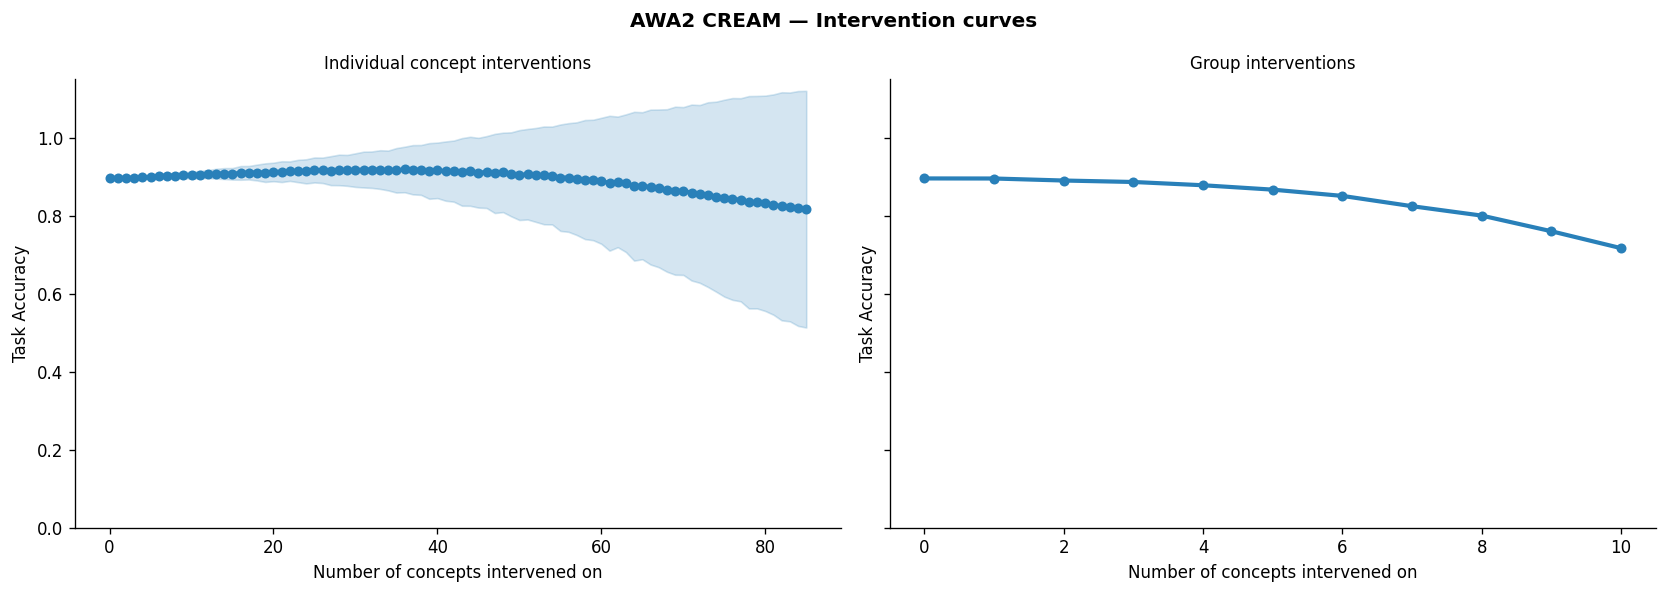

Full intervention (10 concepts): 0.7172 ± nan


In [7]:
if 'iv' in dir() and len(iv) > 0:
    has_group = 'group_interventions' in iv.columns

    fig, axes = plt.subplots(1, 2 if has_group else 1,
                             figsize=(14 if has_group else 7, 5),
                             sharey=True)
    if not has_group:
        axes = [axes]
    fig.suptitle('AWA2 CREAM — Intervention curves', fontsize=12, fontweight='bold')

    for ax, group_flag, label in [
        (axes[0], False, 'Individual concept interventions'),
        *( [(axes[1], True,  'Group interventions')] if has_group else [] )
    ]:
        subset = iv[iv['group_interventions'] == group_flag] if has_group else iv
        agg = subset.groupby('num_interventions')['test_task_accuracy'].agg(['mean', 'std']).reset_index()
        ax.plot(agg['num_interventions'], agg['mean'], lw=2.5, marker='o', markersize=5, color='#2980b9')
        ax.fill_between(agg['num_interventions'],
                        agg['mean'] - agg['std'],
                        agg['mean'] + agg['std'],
                        alpha=0.2, color='#2980b9')
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('Number of concepts intervened on')
        ax.set_ylabel('Task Accuracy')
        ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

    # Print final accuracy at full intervention
    max_iv = agg.iloc[-1]
    print(f"Full intervention ({int(max_iv['num_interventions'])} concepts): "
          f"{max_iv['mean']:.4f} ± {max_iv['std']:.4f}")